# FairScope — Jurisdiction-Aware Fair Lending Compliance Tool
### HSBC Retail Credit | US (Regulation B) vs UK (FCA Consumer Duty)

This notebook builds and demonstrates FairScope, a prototype compliance monitoring tool for HSBC's retail credit business. The goal is to show how the same credit application data needs to be handled differently depending on whether the applicant is in the US or the UK, because the regulatory rules are different in each country.

**What this notebook covers:**
1. Jurisdiction configuration — the rules that govern each pipeline
2. Synthetic data generation — 500 US and 300 UK credit applications
3. Jurisdiction routing — deciding which pipeline each application goes through
4. US pipeline — BISG race estimation, ML model, SHAP explainability, four-fifths test
5. UK pipeline — self-declared ethnicity, ML model, SHAP explainability, Consumer Duty classification
6. Cross-jurisdiction comparison — same SHAP proxy signal, different regulatory response
7. Compliance report generation

**A quick note on SHAP:**
SHAP (SHapley Additive exPlanations) is a method for explaining what a machine learning model is doing. It tells you how much each input feature (like credit score or zip code) contributed to a specific prediction. A positive SHAP value means that feature pushed the model toward approving the application; a negative value means it pushed toward denial. I'm using SHAP here mainly to detect whether geographic features like zip code are acting as hidden proxies for race — which is a fair lending concern under both Regulation B and the Consumer Duty.


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
from datetime import datetime

# Machine learning
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

# SHAP for explainability
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries loaded successfully")
print("Run date:", datetime.now().strftime('%Y-%m-%d %H:%M'))
print("SHAP version:", shap.__version__)


Libraries loaded successfully
Run date: 2026-05-20 21:19
SHAP version: 0.51.0


## Section 1 — Jurisdiction Configuration System

One of the key design decisions in FairScope is that the rules for each country are stored as versioned configuration records, not hardcoded into the analysis logic. This means when a regulation changes (like the CFPB's April 2026 Regulation B update), we update the config record rather than editing the code. Old records are kept and archived so we can always show which rules applied to which application.

The two active configs are:
- **US_CONFIG** — based on Regulation B / CFPB rules
- **UK_CONFIG** — based on FCA Consumer Duty and Equality Act 2010


In [2]:
# US jurisdiction configuration
# This reflects the post-April 2026 position where CFPB no longer pursues ECOA disparate impact,
# but we still run the four-fifths test internally for litigation and state-law risk
US_CONFIG = {
    "config_id": "US_CFPB_RegB_2026-04-15",
    "status": "ACTIVE",
    "supersedes": "US_CFPB_RegB_2021-10-01",
    "jurisdiction": "US",
    "fairness_standard": "four_fifths_ratio",
    "fairness_threshold": 0.80,
    "race_inference_method": "BISG",
    "bisg_inconclusive_threshold": 0.40,
    "adverse_action_notice": "Regulation_B_ECOA",
    "human_review_triggers": [
        "four_fifths_breach",
        "bisg_inconclusive",
        "shap_proxy_alert",
        "model_version_change"
    ],
    "shap_proxy_alert_threshold": 0.15,
    "reporting": ["HMDA", "internal_disparity_report"],
    "effective_date": "2026-04-15",
}

# UK jurisdiction configuration
# Uses self-declared ethnicity only — BISG is deliberately not used here
# because applying a US surname/geocoding model to UK data would be inaccurate
# and inferring ethnicity from names/postcodes raises UK GDPR concerns
UK_CONFIG = {
    "config_id": "UK_FCA_ConsumerDuty_2023-07-31",
    "status": "ACTIVE",
    "supersedes": None,
    "jurisdiction": "UK",
    "fairness_standard": "consumer_duty_outcome",
    "race_inference_method": "self_declaration_only",
    "non_response_alert_threshold": 0.35,
    "adverse_action_notice": "FCA_Consumer_Duty",
    "human_review_triggers": [
        "consumer_duty_review_required",
        "non_response_rate_high",
        "shap_proxy_alert",
        "model_version_change"
    ],
    "shap_proxy_alert_threshold": 0.15,
    "reporting": ["consumer_duty_board_report", "internal_monitoring_feed"],
    "effective_date": "2023-07-31",
}

print("US Config:", US_CONFIG["config_id"], "| Status:", US_CONFIG["status"])
print("UK Config:", UK_CONFIG["config_id"], "| Status:", UK_CONFIG["status"])
print()
print("US fairness standard:", US_CONFIG["fairness_standard"], "| threshold:", US_CONFIG["fairness_threshold"])
print("UK fairness standard:", UK_CONFIG["fairness_standard"])
print("SHAP proxy alert threshold (both pipelines):", US_CONFIG["shap_proxy_alert_threshold"])


US Config: US_CFPB_RegB_2026-04-15 | Status: ACTIVE
UK Config: UK_FCA_ConsumerDuty_2023-07-31 | Status: ACTIVE

US fairness standard: four_fifths_ratio | threshold: 0.8
UK fairness standard: consumer_duty_outcome
SHAP proxy alert threshold (both pipelines): 0.15


## Section 2 — Synthetic Data Generation

All data used in this notebook is synthetic. No real applicant data is used. I generated 500 US applications and 300 UK applications.

For the US data, I used surname groups based on US Census data (this is what BISG relies on) and zip codes with known demographic compositions from the ACS. Credit feature distributions (FICO scores, DTI ratios) are based on published CFPB research showing real group-level differences. Importantly, race does not enter the approval model — the disparities arise from correlated credit features, which is the realistic scenario BISG is designed to detect.

For the UK data, I used ONS ethnicity categories and postcode areas. About 30% of applicants are set to "Prefer not to say" which matches the non-response rate FCA has observed in voluntary equality monitoring.


In [3]:
# Surname groups used for BISG estimation
# Each group contains surnames that are predominantly associated with that racial group
# in US Census surname frequency data
SURNAMES = {
    'White': [
        'Smith', 'Johnson', 'Brown', 'Jones', 'Davis', 'Miller', 'Wilson',
        'Moore', 'Taylor', 'Anderson', 'Thomas', 'White', 'Harris', 'Martin',
        'Thompson', 'Baker', 'Adams', 'Nelson', 'Roberts', 'Phillips'
    ],
    'Black': [
        'Washington', 'Jefferson', 'Robinson', 'Walker', 'Hall', 'Allen',
        'Young', 'King', 'Scott', 'Green', 'Carter', 'Mitchell', 'Turner',
        'Jackson', 'Williams'
    ],
    'Hispanic': [
        'Rodriguez', 'Garcia', 'Martinez', 'Lopez', 'Hernandez', 'Gonzalez',
        'Ramirez', 'Flores', 'Torres', 'Rivera', 'Morales', 'Ortiz', 'Reyes',
        'Cruz', 'Chavez', 'Ramos', 'Sanchez', 'Perez'
    ],
    'Asian': [
        'Chen', 'Kim', 'Nguyen', 'Patel', 'Wang', 'Lee', 'Zhang', 'Singh',
        'Liu', 'Park', 'Kumar', 'Sharma', 'Li', 'Wu', 'Zhou', 'Yang', 'Huang', 'Lin'
    ]
}

# Approximate racial composition by zip code, based on ACS 5-year estimates
# These are used in the BISG geographic adjustment step
ZIP_DEMOGRAPHICS = {
    '10001': {'White': 0.65, 'Black': 0.10, 'Hispanic': 0.15, 'Asian': 0.10},  # Manhattan
    '11201': {'White': 0.55, 'Black': 0.20, 'Hispanic': 0.15, 'Asian': 0.10},  # Brooklyn
    '90001': {'White': 0.10, 'Black': 0.15, 'Hispanic': 0.70, 'Asian': 0.05},  # South LA
    '60601': {'White': 0.60, 'Black': 0.20, 'Hispanic': 0.12, 'Asian': 0.08},  # Chicago Loop
    '77001': {'White': 0.35, 'Black': 0.25, 'Hispanic': 0.35, 'Asian': 0.05},  # Houston
    '19101': {'White': 0.45, 'Black': 0.40, 'Hispanic': 0.10, 'Asian': 0.05},  # Philadelphia
    '94101': {'White': 0.45, 'Black': 0.06, 'Hispanic': 0.15, 'Asian': 0.34},  # San Francisco
    '30301': {'White': 0.40, 'Black': 0.50, 'Hispanic': 0.06, 'Asian': 0.04},  # Atlanta
    '98101': {'White': 0.60, 'Black': 0.07, 'Hispanic': 0.08, 'Asian': 0.25},  # Seattle
    '02101': {'White': 0.65, 'Black': 0.22, 'Hispanic': 0.08, 'Asian': 0.05},  # Boston
}

# National US racial composition (ACS 2020) — used as the BISG baseline prior
US_NATIONAL_PRIOR = {
    'White': 0.595,
    'Black': 0.133,
    'Hispanic': 0.186,
    'Asian': 0.059,
    'Other': 0.027
}

print("Reference data loaded")
print("Zip codes in dataset:", list(ZIP_DEMOGRAPHICS.keys()))


Reference data loaded
Zip codes in dataset: ['10001', '11201', '90001', '60601', '77001', '19101', '94101', '30301', '98101', '02101']


In [4]:
def generate_us_data(n=500, seed=42):
    np.random.seed(seed)

    races = ['White', 'Black', 'Hispanic', 'Asian']
    # Approximate US population shares
    race_weights = [0.55, 0.20, 0.17, 0.08]

    records = []

    for i in range(n):
        # Pick a racial group and a surname from that group
        race = np.random.choice(races, p=race_weights)
        surname = np.random.choice(SURNAMES[race])

        # Pick a zip code and state randomly
        zip_code = np.random.choice(list(ZIP_DEMOGRAPHICS.keys()))
        state = np.random.choice(['NY', 'CA', 'IL', 'TX', 'PA', 'GA', 'WA', 'MA'])

        # Set credit profile mean values based on published group-level disparity data
        # Source: CFPB credit access reports and Urban Institute research
        if race == 'White':
            fico_mean = 700
            dti_mean = 0.32
        elif race == 'Asian':
            fico_mean = 712
            dti_mean = 0.30
        elif race == 'Black':
            fico_mean = 663
            dti_mean = 0.38
        else:  # Hispanic
            fico_mean = 670
            dti_mean = 0.37

        # Generate FICO and DTI with some random variation around the mean
        fico = np.random.normal(fico_mean, 60)
        fico = max(500, min(850, fico))  # clip to realistic range

        dti = np.random.normal(dti_mean, 0.08)
        dti = max(0.10, min(0.60, dti))

        # Pick a loan purpose and generate a realistic loan amount
        loan_purpose = np.random.choice(['mortgage', 'auto', 'personal'], p=[0.50, 0.30, 0.20])

        if loan_purpose == 'mortgage':
            loan_amount = np.exp(np.random.normal(12.5, 0.5))
        elif loan_purpose == 'auto':
            loan_amount = np.exp(np.random.normal(10.2, 0.5))
        else:
            loan_amount = np.exp(np.random.normal(9.5, 0.5))

        # Approval decision — based purely on FICO and DTI, race is not a variable
        # Using a logistic function so higher FICO and lower DTI = higher approval probability
        logit = (fico - 660) / 80 - (dti - 0.30) / 0.12
        approval_prob = 1 / (1 + np.exp(-logit))
        approved = int(np.random.random() < approval_prob)

        record = {
            'applicant_id': 'US-' + str(i + 1).zfill(4),
            'jurisdiction': 'US',
            'surname': surname,
            'true_race': race,          # ground truth — only used to validate BISG, not in the model
            'zip_code': zip_code,
            'state': state,
            'fico_score': round(fico),
            'dti_ratio': round(dti, 3),
            'loan_purpose': loan_purpose,
            'loan_amount': round(loan_amount),
            'approved': approved
        }
        records.append(record)

    return pd.DataFrame(records)


def generate_uk_data(n=300, seed=43):
    np.random.seed(seed)

    areas = ['London', 'Manchester', 'Birmingham', 'Leeds', 'Bristol', 'Edinburgh', 'Cardiff']
    ethnicity_categories = ['White British', 'Asian British', 'Black British', 'Mixed', 'Other']

    # Approximate ethnicity distribution by area (ONS 2021 Census)
    area_ethnicity_weights = {
        'London':     [0.45, 0.18, 0.15, 0.12, 0.10],
        'Manchester': [0.65, 0.12, 0.08, 0.08, 0.07],
        'Birmingham': [0.50, 0.25, 0.10, 0.10, 0.05],
        'Leeds':      [0.75, 0.08, 0.08, 0.05, 0.04],
        'Bristol':    [0.78, 0.06, 0.06, 0.05, 0.05],
        'Edinburgh':  [0.85, 0.05, 0.04, 0.03, 0.03],
        'Cardiff':    [0.80, 0.06, 0.05, 0.05, 0.04],
    }

    # Credit profile means by ethnicity (FCA research)
    # Format: (credit_score_mean, credit_score_sd, dti_mean, dti_sd)
    ethnicity_credit_profiles = {
        'White British':     (620, 70, 0.33, 0.08),
        'Asian British':     (625, 65, 0.31, 0.07),
        'Black British':     (590, 75, 0.39, 0.09),
        'Mixed':             (605, 70, 0.36, 0.08),
        'Other':             (603, 72, 0.36, 0.09),
        'Prefer not to say': (610, 73, 0.35, 0.09),
    }

    records = []

    for i in range(n):
        area = np.random.choice(areas)

        # About 30% of applicants choose not to declare their ethnicity
        if np.random.random() < 0.30:
            ethnicity = 'Prefer not to say'
            ethnicity_declared = False
        else:
            weights = area_ethnicity_weights[area]
            ethnicity = np.random.choice(ethnicity_categories, p=weights)
            ethnicity_declared = True

        # Get the credit profile for this ethnicity
        cs_mean, cs_sd, dti_mean, dti_sd = ethnicity_credit_profiles[ethnicity]

        credit_score = np.random.normal(cs_mean, cs_sd)
        credit_score = max(300, min(750, credit_score))

        dti = np.random.normal(dti_mean, dti_sd)
        dti = max(0.10, min(0.60, dti))

        loan_purpose = np.random.choice(['mortgage', 'auto', 'personal'], p=[0.45, 0.25, 0.30])

        if loan_purpose == 'mortgage':
            loan_amount = np.exp(np.random.normal(12.3, 0.5))
        elif loan_purpose == 'auto':
            loan_amount = np.exp(np.random.normal(9.8, 0.5))
        else:
            loan_amount = np.exp(np.random.normal(9.2, 0.5))

        logit = (credit_score - 500) / 90 - (dti - 0.30) / 0.12
        approval_prob = 1 / (1 + np.exp(-logit))
        approved = int(np.random.random() < approval_prob)

        # Consumer Duty outcome classification for declined applications
        if approved == 1:
            cd_outcome = 'Good outcome'
        elif dti > 0.45 or credit_score < 420:
            cd_outcome = 'Fair outcome - financial risk'
        else:
            cd_outcome = 'Review required'

        record = {
            'applicant_id': 'UK-' + str(i + 1).zfill(4),
            'jurisdiction': 'UK',
            'postcode_area': area,
            'ethnicity': ethnicity,
            'ethnicity_declared': ethnicity_declared,
            'credit_score': round(credit_score),
            'dti_ratio': round(dti, 3),
            'loan_purpose': loan_purpose,
            'loan_amount': round(loan_amount),
            'approved': approved,
            'cd_outcome': cd_outcome
        }
        records.append(record)

    return pd.DataFrame(records)


# Generate both datasets
us_df = generate_us_data(n=500)
uk_df = generate_uk_data(n=300)

print("US dataset:", len(us_df), "records")
print("UK dataset:", len(uk_df), "records")
print()
print("US approval rate:", round(us_df['approved'].mean() * 100, 1), "%")
print("UK approval rate:", round(uk_df['approved'].mean() * 100, 1), "%")
print()
print("First 5 US records:")
print(us_df[['applicant_id', 'surname', 'zip_code', 'fico_score', 'dti_ratio', 'loan_purpose', 'approved']].head())


US dataset: 500 records
UK dataset: 300 records

US approval rate: 48.6 %
UK approval rate: 68.0 %

First 5 US records:
  applicant_id   surname zip_code  fico_score  dti_ratio loan_purpose  \
0      US-0001  Thompson    30301         628      0.491     mortgage   
1      US-0002      Hall    11201         633      0.342     mortgage   
2      US-0003     White    98101         554      0.368     mortgage   
3      US-0004    Nguyen    77001         666      0.258     mortgage   
4      US-0005     Green    98101         680      0.329     mortgage   

   approved  
0         0  
1         1  
2         0  
3         0  
4         1  


## Section 3 — Jurisdiction Router

The first thing FairScope does with any application is decide which pipeline it belongs to. This is based on the jurisdiction field in the application record. If the field is missing or has an unexpected value, the application goes to a human exception queue — it is never processed silently with a default, because if a UK application accidentally went through the US pipeline, BISG would be run on it, which would violate UK GDPR rules around inferring ethnicity from name/postcode.


In [5]:
def route_application(jurisdiction_flag):
    # Route to the correct pipeline based on the jurisdiction field
    if jurisdiction_flag == 'US':
        return 'us_pipeline'
    elif jurisdiction_flag == 'UK':
        return 'uk_pipeline'
    else:
        # Unknown or missing jurisdiction — send to human review
        return 'human_exception_queue'


# Apply the router to both datasets
us_df['route'] = us_df['jurisdiction'].apply(route_application)
uk_df['route'] = uk_df['jurisdiction'].apply(route_application)

# Check that all records routed correctly
print("Routing results:")
print()
print("US applications:")
print(us_df['route'].value_counts())
print()
print("UK applications:")
print(uk_df['route'].value_counts())


Routing results:

US applications:
route
us_pipeline    500
Name: count, dtype: int64

UK applications:
route
uk_pipeline    300
Name: count, dtype: int64


## Section 4 — US Pipeline: BISG Race Estimation

**What is BISG?**

BISG stands for Bayesian Improved Surname Geocoding. It is a method developed by RAND and adopted by the CFPB to estimate the probability that someone belongs to a given racial/ethnic group, without asking them directly. This matters because Regulation B prohibits lenders from collecting race data on most loan applications, but fair lending analysis requires knowing whether outcomes differ by race.

BISG combines two sources of information:
1. **Surname prior** — how commonly is this surname associated with each racial group? (from US Census 2010 surname data)
2. **Geographic prior** — what is the racial composition of the applicant's zip code? (from ACS estimates)

The Bayesian update formula is:

$$P(race \mid surname, zip) \propto P(race \mid surname) \times P(race \mid zip) \div P(race)_{national}$$

The result is a probability vector across five groups. We use the highest-probability group for aggregate monitoring only — never to make decisions about individual applicants.

BISG is **not** run on UK applicants. The UK pipeline uses self-declared data instead.


In [6]:
# Surname to race probability lookup table
# Based on US Census 2010 surname frequency data (CFPB BISG methodology)
# Each entry gives the probability that a person with that surname belongs to each group

BISG_PRIORS = {
    # White-majority surnames
    'Smith':      {'White': 0.73, 'Black': 0.22, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Johnson':    {'White': 0.58, 'Black': 0.34, 'Hispanic': 0.04, 'Asian': 0.01, 'Other': 0.03},
    'Brown':      {'White': 0.58, 'Black': 0.35, 'Hispanic': 0.04, 'Asian': 0.01, 'Other': 0.02},
    'Jones':      {'White': 0.57, 'Black': 0.38, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Davis':      {'White': 0.62, 'Black': 0.31, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.03},
    'Miller':     {'White': 0.84, 'Black': 0.11, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Wilson':     {'White': 0.69, 'Black': 0.25, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Moore':      {'White': 0.66, 'Black': 0.28, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Taylor':     {'White': 0.70, 'Black': 0.24, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Anderson':   {'White': 0.76, 'Black': 0.18, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Thomas':     {'White': 0.55, 'Black': 0.38, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.04},
    'White':      {'White': 0.72, 'Black': 0.21, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.03},
    'Harris':     {'White': 0.59, 'Black': 0.34, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.03},
    'Martin':     {'White': 0.71, 'Black': 0.17, 'Hispanic': 0.07, 'Asian': 0.01, 'Other': 0.04},
    'Thompson':   {'White': 0.78, 'Black': 0.17, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Baker':      {'White': 0.83, 'Black': 0.12, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Adams':      {'White': 0.76, 'Black': 0.18, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Nelson':     {'White': 0.79, 'Black': 0.15, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.02},
    'Roberts':    {'White': 0.78, 'Black': 0.16, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.02},
    'Phillips':   {'White': 0.80, 'Black': 0.15, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    # Black-majority surnames
    'Washington': {'White': 0.14, 'Black': 0.81, 'Hispanic': 0.02, 'Asian': 0.00, 'Other': 0.03},
    'Jefferson':  {'White': 0.23, 'Black': 0.71, 'Hispanic': 0.02, 'Asian': 0.00, 'Other': 0.04},
    'Robinson':   {'White': 0.53, 'Black': 0.41, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Walker':     {'White': 0.67, 'Black': 0.28, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Hall':       {'White': 0.71, 'Black': 0.24, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Allen':      {'White': 0.66, 'Black': 0.28, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.02},
    'Young':      {'White': 0.72, 'Black': 0.22, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.02},
    'King':       {'White': 0.71, 'Black': 0.23, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Scott':      {'White': 0.69, 'Black': 0.25, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Green':      {'White': 0.67, 'Black': 0.28, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Carter':     {'White': 0.62, 'Black': 0.32, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.03},
    'Mitchell':   {'White': 0.73, 'Black': 0.22, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Turner':     {'White': 0.68, 'Black': 0.27, 'Hispanic': 0.02, 'Asian': 0.01, 'Other': 0.02},
    'Jackson':    {'White': 0.39, 'Black': 0.53, 'Hispanic': 0.04, 'Asian': 0.01, 'Other': 0.03},
    'Williams':   {'White': 0.48, 'Black': 0.45, 'Hispanic': 0.03, 'Asian': 0.01, 'Other': 0.03},
    # Hispanic-majority surnames
    'Rodriguez':  {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Garcia':     {'White': 0.06, 'Black': 0.01, 'Hispanic': 0.90, 'Asian': 0.01, 'Other': 0.02},
    'Martinez':   {'White': 0.05, 'Black': 0.01, 'Hispanic': 0.92, 'Asian': 0.00, 'Other': 0.02},
    'Lopez':      {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Hernandez':  {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Gonzalez':   {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Ramirez':    {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Flores':     {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.92, 'Asian': 0.00, 'Other': 0.03},
    'Torres':     {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Rivera':     {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Morales':    {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Ortiz':      {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Reyes':      {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Cruz':       {'White': 0.04, 'Black': 0.02, 'Hispanic': 0.92, 'Asian': 0.00, 'Other': 0.02},
    'Chavez':     {'White': 0.04, 'Black': 0.00, 'Hispanic': 0.94, 'Asian': 0.00, 'Other': 0.02},
    'Ramos':      {'White': 0.04, 'Black': 0.01, 'Hispanic': 0.93, 'Asian': 0.00, 'Other': 0.02},
    'Sanchez':    {'White': 0.05, 'Black': 0.01, 'Hispanic': 0.92, 'Asian': 0.00, 'Other': 0.02},
    'Perez':      {'White': 0.05, 'Black': 0.01, 'Hispanic': 0.92, 'Asian': 0.00, 'Other': 0.02},
    # Asian-majority surnames
    'Chen':   {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Kim':    {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Nguyen': {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Patel':  {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Wang':   {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Lee':    {'White': 0.05, 'Black': 0.01, 'Hispanic': 0.03, 'Asian': 0.88, 'Other': 0.03},
    'Zhang':  {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Singh':  {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Liu':    {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Park':   {'White': 0.03, 'Black': 0.00, 'Hispanic': 0.02, 'Asian': 0.93, 'Other': 0.02},
    'Kumar':  {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Sharma': {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Li':     {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Wu':     {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Zhou':   {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Yang':   {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Huang':  {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.01, 'Asian': 0.97, 'Other': 0.01},
    'Lin':    {'White': 0.01, 'Black': 0.00, 'Hispanic': 0.03, 'Asian': 0.94, 'Other': 0.02},
}

RACES = ['White', 'Black', 'Hispanic', 'Asian', 'Other']

print("BISG surname prior table loaded:", len(BISG_PRIORS), "surnames")


BISG surname prior table loaded: 71 surnames


In [7]:
def run_bisg(surname, zip_code):
    '''
    Run BISG for one applicant.
    Returns a dict of {race: probability} that sums to 1.
    '''

    # Step 1: Get the surname-based prior probabilities
    # If surname is not in our lookup table, fall back to national average
    if surname in BISG_PRIORS:
        surname_probs = BISG_PRIORS[surname]
    else:
        surname_probs = US_NATIONAL_PRIOR

    surname_array = np.array([surname_probs.get(r, 0.001) for r in RACES])

    # Step 2: Get the geographic prior from the zip code demographics
    zip_data = ZIP_DEMOGRAPHICS.get(zip_code, {})

    # Build the geographic probability array
    # 'Other' is not in the zip table so we estimate it as 1 minus the known groups
    geo_array = np.zeros(len(RACES))
    for j, race in enumerate(RACES):
        if race == 'Other':
            # Fill 'Other' as whatever is left after the main four groups
            known_total = sum(geo_array[:4])
            geo_array[j] = max(0.001, 1.0 - known_total)
        else:
            geo_array[j] = zip_data.get(race, 0.02)

    # Step 3: Get the national prior (used to normalise the update)
    national_array = np.array([US_NATIONAL_PRIOR.get(r, 0.02) for r in RACES])

    # Step 4: Bayesian update
    # posterior is proportional to surname_prior * geo_prior / national_prior
    posterior = surname_array * geo_array / (national_array + 1e-9)

    # Step 5: Normalise so probabilities sum to 1
    posterior = posterior / posterior.sum()

    # Return as a dictionary
    result = {}
    for j, race in enumerate(RACES):
        result[race] = posterior[j]

    return result


# Test BISG on one example to make sure it works
test_result = run_bisg('Rodriguez', '90001')
print("BISG test — surname: Rodriguez, zip: 90001 (South LA)")
for race, prob in test_result.items():
    print(f"  {race}: {prob:.3f}")


BISG test — surname: Rodriguez, zip: 90001 (South LA)
  White: 0.002
  Black: 0.003
  Hispanic: 0.995
  Asian: 0.000
  Other: 0.000


In [8]:
# Apply BISG to all US applicants
# Loop through each row and get the race probability vector

bisg_results = []

for idx, row in us_df.iterrows():
    result = run_bisg(row['surname'], row['zip_code'])
    bisg_results.append(result)

# Convert the list of dicts to a dataframe
bisg_df = pd.DataFrame(bisg_results)

# Rename columns to make it clear these are BISG estimates
bisg_df = bisg_df.rename(columns={
    'White': 'bisg_white',
    'Black': 'bisg_black',
    'Hispanic': 'bisg_hispanic',
    'Asian': 'bisg_asian',
    'Other': 'bisg_other'
})

# Add BISG columns to the main US dataframe
us_df = pd.concat([us_df.reset_index(drop=True), bisg_df.reset_index(drop=True)], axis=1)

# Find the most likely race for each applicant (the group with the highest probability)
race_cols = ['bisg_white', 'bisg_black', 'bisg_hispanic', 'bisg_asian', 'bisg_other']

us_df['bisg_estimated_race'] = us_df[race_cols].idxmax(axis=1)
# Clean up the column name prefix — 'bisg_white' becomes 'White'
us_df['bisg_estimated_race'] = us_df['bisg_estimated_race'].str.replace('bisg_', '').str.title()

# Also store the highest probability value
us_df['bisg_max_prob'] = us_df[race_cols].max(axis=1)

# Flag cases where the top probability is below the threshold — these go to human review
inconclusive_threshold = US_CONFIG['bisg_inconclusive_threshold']
us_df['bisg_inconclusive'] = us_df['bisg_max_prob'] < inconclusive_threshold

print("BISG estimation complete")
print()
print("Estimated race distribution:")
print(us_df['bisg_estimated_race'].value_counts())
print()
print("Inconclusive cases (max prob < " + str(inconclusive_threshold) + "):", us_df['bisg_inconclusive'].sum())
print("That is", round(us_df['bisg_inconclusive'].mean() * 100, 1), "% of all US applications")
print("These will be sent to human review queue")


BISG estimation complete

Estimated race distribution:
bisg_estimated_race
White       240
Black       135
Hispanic     89
Asian        36
Name: count, dtype: int64

Inconclusive cases (max prob < 0.4): 2
That is 0.4 % of all US applications
These will be sent to human review queue


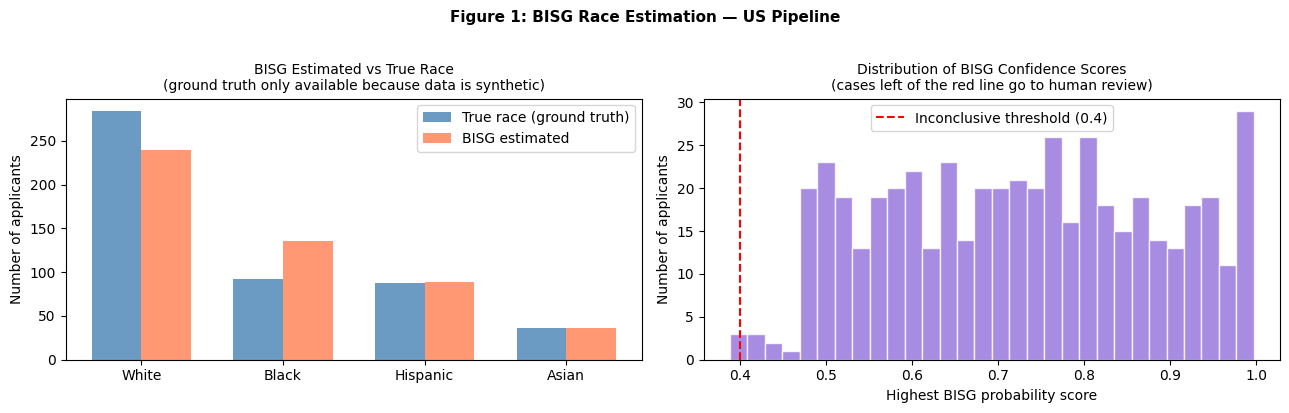

In [9]:
# Figure 1: Compare BISG estimated race vs true race (validation only)
# In a real system we would not have the 'true_race' field —
# this comparison is just to show how well BISG performs on synthetic data

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

race_groups = ['White', 'Black', 'Hispanic', 'Asian']

# Count true vs estimated
true_counts = us_df['true_race'].value_counts()
estimated_counts = us_df['bisg_estimated_race'].value_counts()

x_positions = range(len(race_groups))
bar_width = 0.35

true_vals = [true_counts.get(r, 0) for r in race_groups]
estimated_vals = [estimated_counts.get(r, 0) for r in race_groups]

# Shift bars so they sit side by side
x_left = [x - bar_width/2 for x in x_positions]
x_right = [x + bar_width/2 for x in x_positions]

axes[0].bar(x_left, true_vals, bar_width, label='True race (ground truth)', color='steelblue', alpha=0.8)
axes[0].bar(x_right, estimated_vals, bar_width, label='BISG estimated', color='coral', alpha=0.8)
axes[0].set_xticks(list(x_positions))
axes[0].set_xticklabels(race_groups)
axes[0].set_ylabel('Number of applicants')
axes[0].set_title('BISG Estimated vs True Race\n(ground truth only available because data is synthetic)', fontsize=10)
axes[0].legend()

# Distribution of BISG max probability scores
axes[1].hist(us_df['bisg_max_prob'], bins=30, color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1].axvline(
    x=inconclusive_threshold,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Inconclusive threshold (' + str(inconclusive_threshold) + ')'
)
axes[1].set_xlabel('Highest BISG probability score')
axes[1].set_ylabel('Number of applicants')
axes[1].set_title('Distribution of BISG Confidence Scores\n(cases left of the red line go to human review)', fontsize=10)
axes[1].legend()

plt.suptitle('Figure 1: BISG Race Estimation — US Pipeline', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Section 5 — US Pipeline: ML Credit Model

I am training a Gradient Boosting Classifier (GBM) on the US credit application data. I chose GBM for two reasons:

1. It works well with a mix of numeric features (FICO score, DTI) and categorical features (zip code, loan purpose) without needing to scale them first
2. The SHAP library's `TreeExplainer` gives exact (not approximated) Shapley values for tree-based models, which is what we need for reliable proxy detection

**Important:** race and ethnicity are not included as features. The model only sees credit-risk variables and geographic variables. The point is then to use SHAP to check whether the geographic variables (zip code, state) are behaving like proxies — i.e., whether the model is effectively using them to treat people differently based on race.

The features are:
- `fico_score` — the main credit quality signal
- `dti_ratio` — debt-to-income, the main affordability signal
- `log_loan_amount` — log of the loan amount (log transform because loan amounts are skewed)
- `loan_purpose` — mortgage, auto, or personal (encoded as numbers)
- `zip_code` — encoded as a number (this is the potential proxy we want to monitor)
- `state` — also a potential proxy


In [10]:
# Encode categorical features as integers (sklearn needs numbers not strings)
le_purpose = LabelEncoder()
le_zip = LabelEncoder()
le_state = LabelEncoder()

# Work on a copy so we don't modify the original dataframe
us_model_df = us_df.copy()
us_model_df['loan_purpose_enc'] = le_purpose.fit_transform(us_model_df['loan_purpose'])
us_model_df['zip_code_enc'] = le_zip.fit_transform(us_model_df['zip_code'])
us_model_df['state_enc'] = le_state.fit_transform(us_model_df['state'])

# Log transform the loan amount because loan amounts have a long right tail
us_model_df['log_loan_amount'] = np.log1p(us_model_df['loan_amount'])

# Define which columns are features and what to call them in charts
US_FEATURES = ['fico_score', 'dti_ratio', 'log_loan_amount', 'loan_purpose_enc', 'zip_code_enc', 'state_enc']
US_FEAT_LABELS = ['FICO Score', 'DTI Ratio', 'Log Loan Amount', 'Loan Purpose', 'Zip Code', 'State']

# Build feature matrix and target vector
X_us = us_model_df[US_FEATURES].values
y_us = us_model_df['approved'].values

print("Feature matrix shape:", X_us.shape)
print("Features:", US_FEATURES)
print("Approval rate in target:", round(y_us.mean() * 100, 1), "%")


Feature matrix shape: (500, 6)
Features: ['fico_score', 'dti_ratio', 'log_loan_amount', 'loan_purpose_enc', 'zip_code_enc', 'state_enc']
Approval rate in target: 48.6 %


In [11]:
# Split into training and test sets
X_train_us, X_test_us, y_train_us, y_test_us = train_test_split(
    X_us, y_us,
    test_size=0.25,
    random_state=42,
    stratify=y_us  # keep the same approval rate in train and test
)

print("Training set size:", len(X_train_us))
print("Test set size:", len(X_test_us))
print()

# Train the Gradient Boosting model
us_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

us_model.fit(X_train_us, y_train_us)
print("Model trained")

# Evaluate on the test set
y_pred_us = us_model.predict(X_test_us)
y_prob_us = us_model.predict_proba(X_test_us)[:, 1]  # probability of approval

auc_us = roc_auc_score(y_test_us, y_prob_us)

# Also run 5-fold cross-validation to check the AUC is stable
cv_scores_us = cross_val_score(us_model, X_us, y_us, cv=5, scoring='roc_auc')

print()
print("US Credit Model — Gradient Boosting Classifier")
print("=" * 50)
print("Test AUC:", round(auc_us, 4))
print("5-fold CV AUC:", round(cv_scores_us.mean(), 4), "+/-", round(cv_scores_us.std(), 4))
print()
print(classification_report(y_test_us, y_pred_us, target_names=['Denied', 'Approved']))


Training set size: 375
Test set size: 125

Model trained

US Credit Model — Gradient Boosting Classifier
Test AUC: 0.7395
5-fold CV AUC: 0.7098 +/- 0.0423

              precision    recall  f1-score   support

      Denied       0.65      0.67      0.66        64
    Approved       0.64      0.62      0.63        61

    accuracy                           0.65       125
   macro avg       0.65      0.65      0.65       125
weighted avg       0.65      0.65      0.65       125



## Section 6 — US Pipeline: SHAP Explainability

Now that the model is trained, I run SHAP on it. SHAP (SHapley Additive exPlanations) tells us how much each feature contributed to each prediction.

The formula is:

$$f(x) = \phi_0 + \sum_{i=1}^{n} \phi_i$$

where $f(x)$ is the model's prediction for a specific applicant, $\phi_0$ is the base rate (what the model would predict if it knew nothing), and each $\phi_i$ is the SHAP value for feature $i$ — how much that feature moved the prediction up or down.

I use `shap.TreeExplainer` which gives exact Shapley values for tree models. This is important — other SHAP variants use sampling, which adds noise. For a compliance tool, we want deterministic and reproducible explanations.

**What am I looking for?** If `Zip Code` has a large mean absolute SHAP value (meaning the model is using it a lot), and that zip code correlates with race (which we can see from the BISG estimates), then the model is effectively treating people differently based on where they live — which can be a proxy for race. This is the proxy alert trigger in `US_CONFIG`.


In [12]:
# Create the SHAP explainer using the trained US model
us_explainer = shap.TreeExplainer(us_model)

# Compute SHAP values for all test set applicants
# This gives us an array of shape [n_test_applicants, n_features]
shap_explanation_us = us_explainer(X_test_us)
shap_values_us = shap_explanation_us.values  # raw numpy array

print("SHAP values computed")
print("Shape:", shap_values_us.shape, "(applicants x features)")
print()

# Calculate mean absolute SHAP per feature
# This tells us on average how much each feature moves predictions
mean_abs_shap_us = np.abs(shap_values_us).mean(axis=0)

print("Mean absolute SHAP values by feature:")
print("-" * 45)
total_shap = mean_abs_shap_us.sum()
for i, feature_name in enumerate(US_FEAT_LABELS):
    importance = mean_abs_shap_us[i]
    share = importance / total_shap
    # Flag if this geographic feature is above the proxy alert threshold
    if feature_name in ['Zip Code', 'State'] and share > US_CONFIG['shap_proxy_alert_threshold']:
        flag = "  <-- PROXY ALERT"
    else:
        flag = ""
    print(f"  {feature_name:<20}: {importance:.4f}  ({round(share*100, 1)}%){flag}")

print()

# Check if zip code specifically triggers the proxy alert
zip_feature_idx = US_FEATURES.index('zip_code_enc')
zip_importance_share = mean_abs_shap_us[zip_feature_idx] / total_shap

print("Zip code SHAP share:", round(zip_importance_share * 100, 1), "%")
print("Proxy alert threshold:", round(US_CONFIG['shap_proxy_alert_threshold'] * 100), "%")
print()

if zip_importance_share > US_CONFIG['shap_proxy_alert_threshold']:
    print("[FAIRSCOPE ALERT] Zip code importance exceeds threshold!")
    print("  Action required: CCO and Model Risk team must be notified.")
    print("  Human review required before next quarterly compliance report.")
else:
    print("[FAIRSCOPE] Zip code within threshold — no proxy alert.")


SHAP values computed
Shape: (125, 6) (applicants x features)

Mean absolute SHAP values by feature:
---------------------------------------------
  FICO Score          : 0.8146  (37.3%)
  DTI Ratio           : 0.6795  (31.1%)
  Log Loan Amount     : 0.3379  (15.5%)
  Loan Purpose        : 0.0902  (4.1%)
  Zip Code            : 0.1574  (7.2%)
  State               : 0.1068  (4.9%)

Zip code SHAP share: 7.2 %
Proxy alert threshold: 15 %

[FAIRSCOPE] Zip code within threshold — no proxy alert.


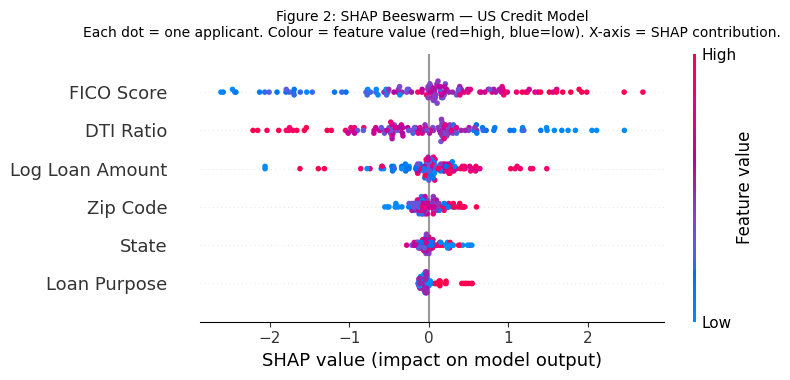

In [13]:
# Figure 2: SHAP Beeswarm Plot
# Each dot is one applicant in the test set
# The x-axis shows how much that feature pushed the prediction toward approval (positive) or denial (negative)
# The colour shows the feature value — red = high value, blue = low value

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values_us, X_test_us, feature_names=US_FEAT_LABELS, show=False)
plt.title(
    'Figure 2: SHAP Beeswarm — US Credit Model\n'
    'Each dot = one applicant. Colour = feature value (red=high, blue=low). X-axis = SHAP contribution.',
    fontsize=10, pad=12
)
plt.tight_layout()
plt.show()


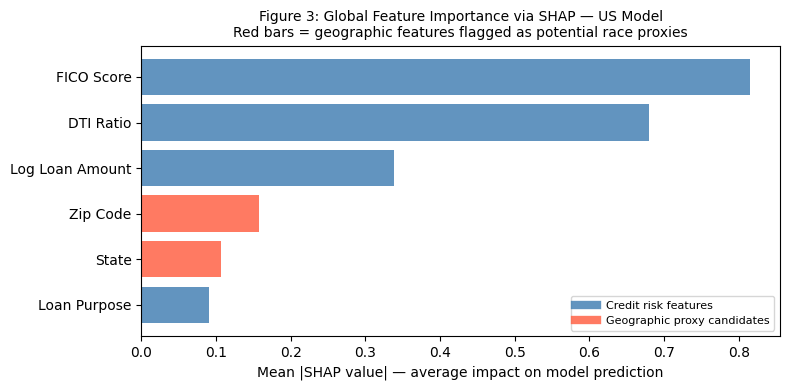

In [14]:
# Figure 3: Global Feature Importance (Mean Absolute SHAP)
# Red bars are the geographic features we are watching for proxy risk

# Build a sorted series for plotting
shap_series_us = {}
for i, name in enumerate(US_FEAT_LABELS):
    shap_series_us[name] = mean_abs_shap_us[i]

# Sort from highest to lowest importance
sorted_features = sorted(shap_series_us.items(), key=lambda x: x[1])
feature_names_sorted = [item[0] for item in sorted_features]
feature_values_sorted = [item[1] for item in sorted_features]

# Colour geographic features red, credit features blue
bar_colours = []
for name in feature_names_sorted:
    if name in ['Zip Code', 'State']:
        bar_colours.append('tomato')
    else:
        bar_colours.append('steelblue')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feature_names_sorted, feature_values_sorted, color=bar_colours, alpha=0.85)
ax.set_xlabel('Mean |SHAP value| — average impact on model prediction')
ax.set_title(
    'Figure 3: Global Feature Importance via SHAP — US Model\n'
    'Red bars = geographic features flagged as potential race proxies',
    fontsize=10
)

# Add a simple manual legend
ax.plot([], [], color='steelblue', linewidth=6, label='Credit risk features', alpha=0.85)
ax.plot([], [], color='tomato', linewidth=6, label='Geographic proxy candidates', alpha=0.85)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


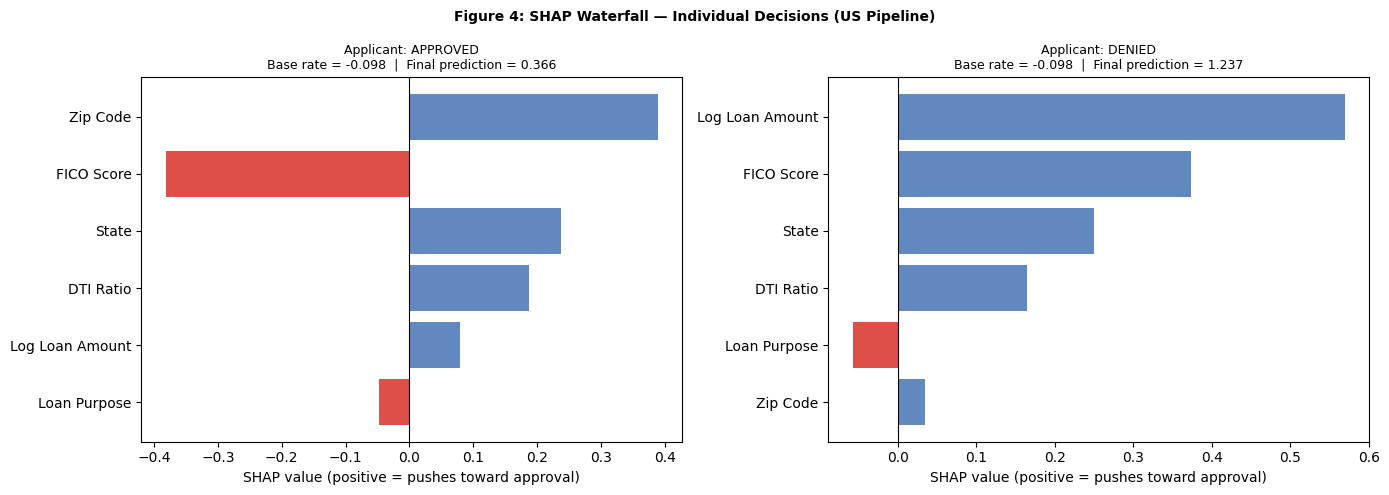

Blue bars push toward approval, red bars push toward denial.
The prediction is the base rate plus all the SHAP values added together.


In [15]:
# Figure 4: SHAP Waterfall — what drove the decision for two individual applicants?
# Find one approved and one denied applicant in the test set

approved_idx = None
denied_idx = None

for i in range(len(y_test_us)):
    if y_test_us[i] == 1 and approved_idx is None:
        approved_idx = i
    if y_test_us[i] == 0 and denied_idx is None:
        denied_idx = i
    if approved_idx is not None and denied_idx is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, applicant_idx, label in [(axes[0], approved_idx, 'APPROVED'), (axes[1], denied_idx, 'DENIED')]:
    # Get the SHAP values for this one applicant
    sv = shap_values_us[applicant_idx]

    # Get the base value (model's average prediction)
    base_val = float(shap_explanation_us.base_values[applicant_idx])

    # Final prediction = base + sum of SHAP values
    final_pred = base_val + sv.sum()

    # Sort features by absolute SHAP value, largest first
    order = np.argsort(np.abs(sv))[::-1]
    sv_sorted = sv[order]
    names_sorted = [US_FEAT_LABELS[j] for j in order]

    # Blue = pushes toward approval, red = pushes toward denial
    bar_colours_w = []
    for val in sv_sorted:
        if val >= 0:
            bar_colours_w.append('#4575b4')  # blue
        else:
            bar_colours_w.append('#d73027')  # red

    # Plot horizontally with most important feature at the top
    ax.barh(names_sorted[::-1], sv_sorted[::-1], color=bar_colours_w[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        'Applicant: ' + label + '\n'
        'Base rate = ' + str(round(base_val, 3)) + '  |  Final prediction = ' + str(round(final_pred, 3)),
        fontsize=9
    )
    ax.set_xlabel('SHAP value (positive = pushes toward approval)')

plt.suptitle('Figure 4: SHAP Waterfall — Individual Decisions (US Pipeline)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print("Blue bars push toward approval, red bars push toward denial.")
print("The prediction is the base rate plus all the SHAP values added together.")


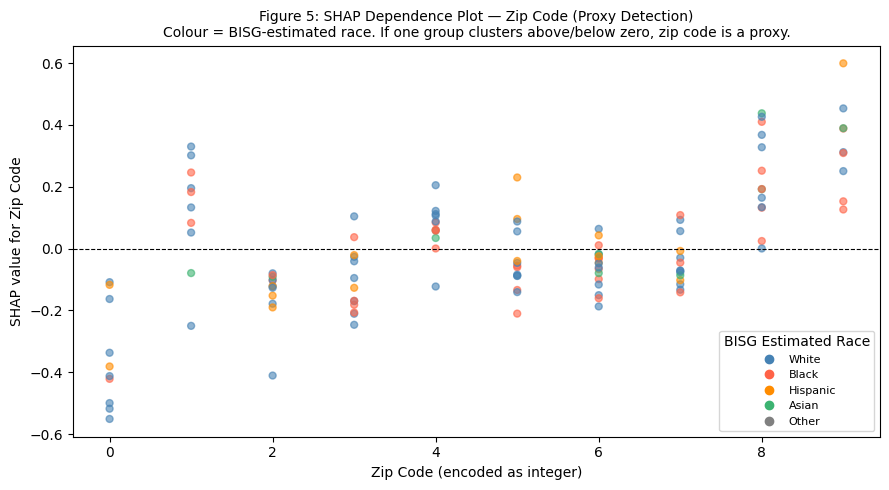

How to read this chart:
  If one racial group's dots sit consistently above SHAP=0, zip code is boosting their approval.
  If one group's dots sit consistently below, zip code is reducing their approval.
  Either pattern means zip code is acting as a proxy for race.


In [16]:
# Figure 5: SHAP Dependence Plot — is zip code a race proxy?
# If we colour the points by the BISG-estimated race of each applicant,
# and we see that one racial group clusters above SHAP=0 and another below,
# that means zip code is being used by the model to treat those groups differently

zip_feature_idx = US_FEATURES.index('zip_code_enc')

# Get the zip code values and SHAP values for all test applicants
zip_encoded_values = X_test_us[:, zip_feature_idx]
zip_shap_values = shap_values_us[:, zip_feature_idx]

# Get the BISG estimated race for the test applicants
# (using the first n_test rows as an approximation since split is deterministic)
n_test = len(X_test_us)
bisg_race_for_test = us_df['bisg_estimated_race'].values[:n_test]

# Assign a colour to each racial group
race_colour_map = {
    'White': 'steelblue',
    'Black': 'tomato',
    'Hispanic': 'darkorange',
    'Asian': 'mediumseagreen',
    'Other': 'gray'
}

point_colours = []
for race in bisg_race_for_test:
    colour = race_colour_map.get(race, 'gray')
    point_colours.append(colour)

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(zip_encoded_values, zip_shap_values, c=point_colours, alpha=0.6, s=25)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Zip Code (encoded as integer)')
ax.set_ylabel('SHAP value for Zip Code')
ax.set_title(
    'Figure 5: SHAP Dependence Plot — Zip Code (Proxy Detection)\n'
    'Colour = BISG-estimated race. If one group clusters above/below zero, zip code is a proxy.',
    fontsize=10
)

# Add a legend manually
for race, colour in race_colour_map.items():
    ax.plot([], [], 'o', color=colour, label=race, markersize=6)
ax.legend(title='BISG Estimated Race', fontsize=8)

plt.tight_layout()
plt.show()

print("How to read this chart:")
print("  If one racial group's dots sit consistently above SHAP=0, zip code is boosting their approval.")
print("  If one group's dots sit consistently below, zip code is reducing their approval.")
print("  Either pattern means zip code is acting as a proxy for race.")


## Section 7 — US Pipeline: Four-Fifths Disparity Analysis

The **four-fifths rule** comes from the EEOC Uniform Guidelines and is used in fair lending analysis. It says: if a minority group's approval rate is less than 80% of the highest approval group's rate, that is a statistical indicator of adverse impact.

$$\text{Four-Fifths Ratio} = \frac{\text{Approval Rate for Group X}}{\text{Approval Rate for Reference Group}} \geq 0.80$$

After April 2026, the CFPB has said it will not pursue ECOA disparate-impact cases. But FairScope still runs this check internally because:
- State law (e.g. California, New York) may still impose disparate-impact liability
- The bank faces litigation risk even without federal enforcement
- Reputational risk from unexplained disparities remains

Note: only conclusive BISG cases are included in this calculation — inconclusive ones were already sent to human review.


In [17]:
# Filter to only conclusive BISG cases
conclusive_us = us_df[us_df['bisg_inconclusive'] == False].copy()
print("Conclusive BISG cases:", len(conclusive_us), "out of", len(us_df))
print()

# Calculate approval rate for each BISG-estimated racial group
approval_by_group = {}

for race in conclusive_us['bisg_estimated_race'].unique():
    group_data = conclusive_us[conclusive_us['bisg_estimated_race'] == race]
    approval_rate = group_data['approved'].mean()
    n = len(group_data)
    approval_by_group[race] = {'approval_rate': approval_rate, 'n': n}

# Find the reference group (highest approval rate)
best_group = max(approval_by_group, key=lambda r: approval_by_group[r]['approval_rate'])
best_rate = approval_by_group[best_group]['approval_rate']

print("Reference group (highest approval rate):", best_group, "at", round(best_rate * 100, 1), "%")
print()

# Calculate four-fifths ratio for each group
print("Four-Fifths Analysis:")
print("-" * 70)
print(f"{'Group':<12} {'N':>6} {'Approval%':>12} {'4/5 Ratio':>12} {'Status':>10}")
print("-" * 70)

alert_groups = []

for race, stats in approval_by_group.items():
    rate = stats['approval_rate']
    n = stats['n']
    ratio = rate / best_rate

    if ratio < US_CONFIG['fairness_threshold']:
        status = 'BREACH'
        alert_groups.append(race)
    else:
        status = 'OK'

    print(f"{race:<12} {n:>6} {round(rate*100,1):>11}% {round(ratio,3):>12} {status:>10}")

print("-" * 70)
print()

if len(alert_groups) > 0:
    print("[FAIRSCOPE ALERT] Four-fifths breach detected for:", alert_groups)
    print("  Threshold:", US_CONFIG['fairness_threshold'])
    print("  Action: CCO notified. HMDA filing flagged for review.")
else:
    print("[FAIRSCOPE] No four-fifths breach detected in this cohort.")


Conclusive BISG cases: 498 out of 500

Reference group (highest approval rate): White at 53.6 %

Four-Fifths Analysis:
----------------------------------------------------------------------
Group             N    Approval%    4/5 Ratio     Status
----------------------------------------------------------------------
Black           134        44.8%        0.836         OK
White           239        53.6%          1.0         OK
Asian            36        52.8%        0.985         OK
Hispanic         89        39.3%        0.734     BREACH
----------------------------------------------------------------------

[FAIRSCOPE ALERT] Four-fifths breach detected for: ['Hispanic']
  Threshold: 0.8
  Action: CCO notified. HMDA filing flagged for review.


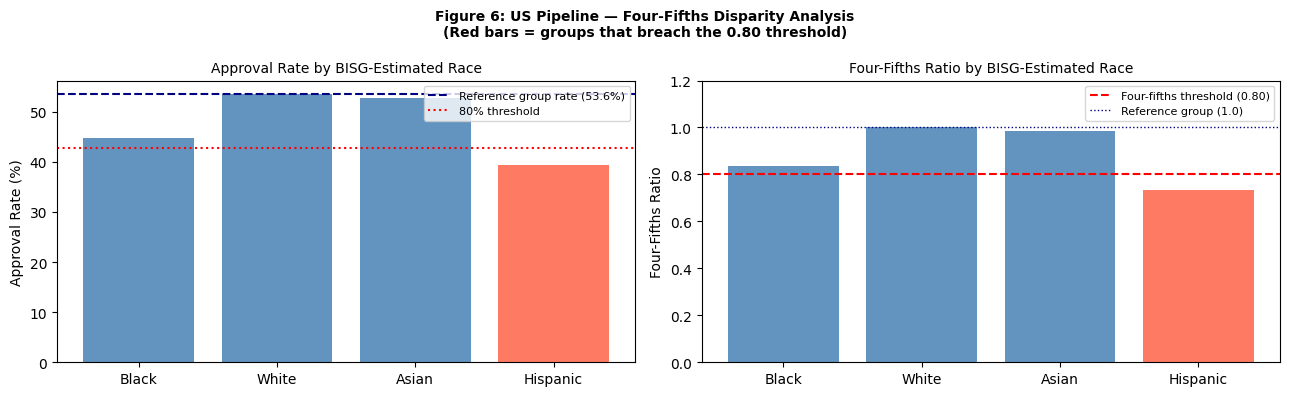

In [18]:
# Figure 6: Four-Fifths Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

groups = list(approval_by_group.keys())
approval_rates_pct = [approval_by_group[g]['approval_rate'] * 100 for g in groups]
four_fifths_ratios = [approval_by_group[g]['approval_rate'] / best_rate for g in groups]

# Colour breaching groups red
colours_bar = []
for g in groups:
    ratio = approval_by_group[g]['approval_rate'] / best_rate
    if ratio < US_CONFIG['fairness_threshold']:
        colours_bar.append('tomato')
    else:
        colours_bar.append('steelblue')

# Left chart: approval rates
axes[0].bar(groups, approval_rates_pct, color=colours_bar, alpha=0.85)
axes[0].axhline(best_rate * 100, color='navy', linestyle='--', linewidth=1.5,
                label='Reference group rate (' + str(round(best_rate*100,1)) + '%)')
axes[0].axhline(best_rate * 100 * US_CONFIG['fairness_threshold'], color='red', linestyle=':',
                linewidth=1.5, label='80% threshold')
axes[0].set_ylabel('Approval Rate (%)')
axes[0].set_title('Approval Rate by BISG-Estimated Race', fontsize=10)
axes[0].legend(fontsize=8)

# Right chart: four-fifths ratios
axes[1].bar(groups, four_fifths_ratios, color=colours_bar, alpha=0.85)
axes[1].axhline(US_CONFIG['fairness_threshold'], color='red', linestyle='--', linewidth=1.5,
                label='Four-fifths threshold (0.80)')
axes[1].axhline(1.0, color='navy', linestyle=':', linewidth=1.0, label='Reference group (1.0)')
axes[1].set_ylabel('Four-Fifths Ratio')
axes[1].set_title('Four-Fifths Ratio by BISG-Estimated Race', fontsize=10)
axes[1].set_ylim(0, 1.2)
axes[1].legend(fontsize=8)

plt.suptitle(
    'Figure 6: US Pipeline — Four-Fifths Disparity Analysis\n'
    '(Red bars = groups that breach the 0.80 threshold)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()


## Section 8 — UK Pipeline: Self-Declaration Analysis

The UK pipeline is completely separate from the US pipeline. The main differences are:

1. **No BISG** — we do not infer ethnicity from names or postcodes. UK applicants who choose to share their ethnicity do so voluntarily. Those who do not say "Prefer not to say" and are excluded from group-level analysis (but the non-response rate itself is reported, because a very high non-response rate would mean our group data is not representative).

2. **Consumer Duty framework** — rather than the four-fifths test, the UK uses a qualitative outcome classification. Each declined application is categorised as a "fair outcome", a "review required" case, or a "good outcome" (appropriate decline).

3. **Self-declared data** — collected under the Equality Act 2010 and UK GDPR. The data is special category data under GDPR and has strict processing restrictions.

The non-response problem is a genuine limitation. About 30% of applicants choose "Prefer not to say". We cannot impute their ethnicity and we do not try to. We just report the non-response rate clearly.


In [19]:
# Calculate the non-response rate
total_uk = len(uk_df)
non_response_count = uk_df[uk_df['ethnicity_declared'] == False].shape[0]
non_response_rate = non_response_count / total_uk

print("UK ethnicity non-response rate:", round(non_response_rate * 100, 1), "%")
print("(" + str(non_response_count) + " out of " + str(total_uk) + " applicants chose 'Prefer not to say')")
print()

if non_response_rate > UK_CONFIG['non_response_alert_threshold']:
    print("[FAIRSCOPE ALERT] Non-response rate exceeds threshold of",
          str(round(UK_CONFIG['non_response_alert_threshold'] * 100)) + "%")
    print("  Action: Senior management alert. Sample may not be representative.")
else:
    print("[FAIRSCOPE] Non-response rate within acceptable range.")

print()
print("Full ethnicity distribution (including non-response):")
print(uk_df['ethnicity'].value_counts())


UK ethnicity non-response rate: 25.0 %
(75 out of 300 applicants chose 'Prefer not to say')

[FAIRSCOPE] Non-response rate within acceptable range.

Full ethnicity distribution (including non-response):
ethnicity
White British        150
Prefer not to say     75
Asian British         31
Black British         16
Mixed                 15
Other                 13
Name: count, dtype: int64


In [20]:
# Calculate approval rates for declared groups only
# Non-responses are excluded from the group analysis
declared_only = uk_df[uk_df['ethnicity_declared'] == True].copy()

print("Declared applicants:", len(declared_only), "out of", len(uk_df))
print()

# Calculate approval rate per ethnicity group
print("Approval rates by declared ethnicity:")
print("-" * 45)
print(f"{'Ethnicity':<22} {'N':>6} {'Approved':>10} {'Rate':>8}")
print("-" * 45)

uk_approval_rates = {}

for ethnicity in declared_only['ethnicity'].unique():
    group = declared_only[declared_only['ethnicity'] == ethnicity]
    n = len(group)
    approved = group['approved'].sum()
    rate = group['approved'].mean()
    uk_approval_rates[ethnicity] = rate
    print(f"  {ethnicity:<20} {n:>6} {approved:>10} {str(round(rate*100,1))+'%':>8}")

print()
print("Consumer Duty outcome breakdown (all UK applicants):")
print(uk_df['cd_outcome'].value_counts())


Declared applicants: 225 out of 300

Approval rates by declared ethnicity:
---------------------------------------------
Ethnicity                   N   Approved     Rate
---------------------------------------------
  White British           150        112    74.7%
  Asian British            31         24    77.4%
  Other                    13          8    61.5%
  Black British            16          6    37.5%
  Mixed                    15          8    53.3%

Consumer Duty outcome breakdown (all UK applicants):
cd_outcome
Good outcome                     204
Review required                   77
Fair outcome - financial risk     19
Name: count, dtype: int64


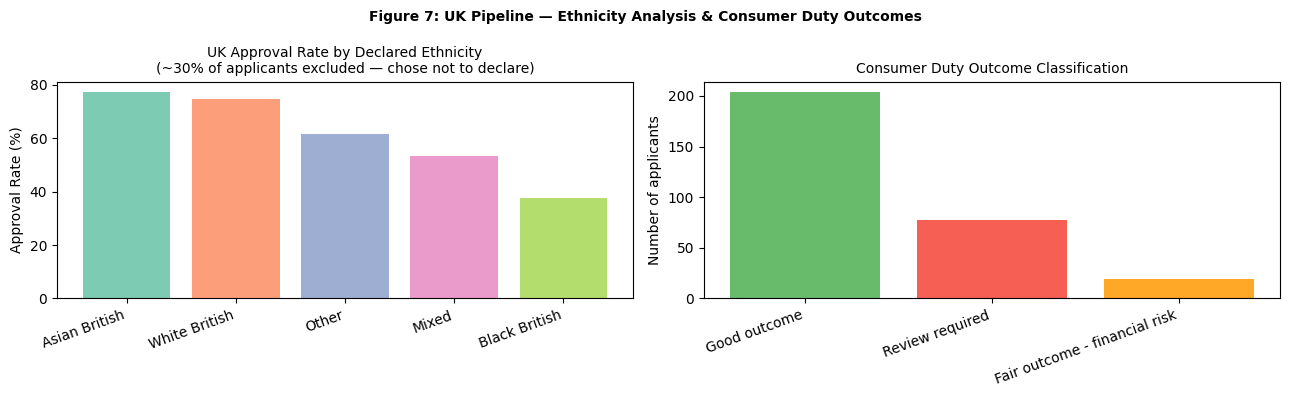

In [21]:
# Figure 7: UK approval rates and Consumer Duty outcomes

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: approval rates by ethnicity (sorted)
sorted_eth = sorted(uk_approval_rates.items(), key=lambda x: x[1], reverse=True)
eth_names = [item[0] for item in sorted_eth]
eth_rates = [item[1] * 100 for item in sorted_eth]

colours_uk = sns.color_palette('Set2', len(eth_names))
axes[0].bar(eth_names, eth_rates, color=colours_uk, alpha=0.85)
axes[0].set_ylabel('Approval Rate (%)')
axes[0].set_xticklabels(eth_names, rotation=20, ha='right')
axes[0].set_title(
    'UK Approval Rate by Declared Ethnicity\n'
    '(~30% of applicants excluded — chose not to declare)',
    fontsize=10
)

# Right: Consumer Duty outcome distribution
outcome_counts = uk_df['cd_outcome'].value_counts()
outcome_colours = {
    'Good outcome': '#4caf50',
    'Fair outcome - financial risk': '#ff9800',
    'Review required': '#f44336'
}
bar_colours_cd = [outcome_colours.get(o, 'gray') for o in outcome_counts.index]
axes[1].bar(outcome_counts.index, outcome_counts.values, color=bar_colours_cd, alpha=0.85)
axes[1].set_ylabel('Number of applicants')
axes[1].set_xticklabels(outcome_counts.index, rotation=20, ha='right')
axes[1].set_title('Consumer Duty Outcome Classification', fontsize=10)

plt.suptitle('Figure 7: UK Pipeline — Ethnicity Analysis & Consumer Duty Outcomes', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 9 — UK Pipeline: ML Credit Model + SHAP

The UK model uses the same Gradient Boosting architecture as the US model, but with different features. The main differences are:
- `credit_score` instead of `fico_score` (UK uses Experian scores, different scale)
- `postcode_area` instead of `zip_code` + `state` (UK geographic unit)
- No ethnicity features — same design principle as the US model

SHAP is then used to check whether `postcode_area` is acting as an ethnicity proxy. If it is, the Consumer Duty response is different from the US four-fifths response — under Consumer Duty the trigger is a compliance officer review and a DPO notification, not a CCO alert and HMDA flag.


In [22]:
# Encode the UK categorical features
le_purpose_uk = LabelEncoder()
le_postcode = LabelEncoder()

uk_model_df = uk_df.copy()
uk_model_df['loan_purpose_enc'] = le_purpose_uk.fit_transform(uk_model_df['loan_purpose'])
uk_model_df['postcode_area_enc'] = le_postcode.fit_transform(uk_model_df['postcode_area'])
uk_model_df['log_loan_amount'] = np.log1p(uk_model_df['loan_amount'])

UK_FEATURES = ['credit_score', 'dti_ratio', 'log_loan_amount', 'loan_purpose_enc', 'postcode_area_enc']
UK_FEAT_LABELS = ['Credit Score', 'DTI Ratio', 'Log Loan Amount', 'Loan Purpose', 'Postcode Area']

X_uk = uk_model_df[UK_FEATURES].values
y_uk = uk_model_df['approved'].values

# Train/test split
X_train_uk, X_test_uk, y_train_uk, y_test_uk = train_test_split(
    X_uk, y_uk, test_size=0.25, random_state=42, stratify=y_uk
)

# Train the UK model — same architecture as US
uk_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=4,
    min_samples_leaf=8,
    random_state=42
)
uk_model.fit(X_train_uk, y_train_uk)

# Evaluate
y_prob_uk = uk_model.predict_proba(X_test_uk)[:, 1]
auc_uk = roc_auc_score(y_test_uk, y_prob_uk)
cv_scores_uk = cross_val_score(uk_model, X_uk, y_uk, cv=5, scoring='roc_auc')

print("UK Credit Model — Gradient Boosting Classifier")
print("=" * 50)
print("Test AUC:", round(auc_uk, 4))
print("5-fold CV AUC:", round(cv_scores_uk.mean(), 4), "+/-", round(cv_scores_uk.std(), 4))


UK Credit Model — Gradient Boosting Classifier
Test AUC: 0.8047
5-fold CV AUC: 0.7124 +/- 0.0318


In [23]:
# Compute SHAP values for the UK model
uk_explainer = shap.TreeExplainer(uk_model)
shap_explanation_uk = uk_explainer(X_test_uk)
shap_values_uk = shap_explanation_uk.values

mean_abs_shap_uk = np.abs(shap_values_uk).mean(axis=0)

print("Mean |SHAP| by Feature — UK Model")
print("-" * 45)
total_shap_uk = mean_abs_shap_uk.sum()

for i, feature_name in enumerate(UK_FEAT_LABELS):
    importance = mean_abs_shap_uk[i]
    share = importance / total_shap_uk
    if feature_name == 'Postcode Area' and share > UK_CONFIG['shap_proxy_alert_threshold']:
        flag = "  <-- PROXY ALERT (Consumer Duty)"
    else:
        flag = ""
    print(f"  {feature_name:<22}: {importance:.4f}  ({round(share*100, 1)}%){flag}")

print()

postcode_idx = UK_FEATURES.index('postcode_area_enc')
postcode_share = mean_abs_shap_uk[postcode_idx] / total_shap_uk

if postcode_share > UK_CONFIG['shap_proxy_alert_threshold']:
    print("[FAIRSCOPE ALERT] Postcode area importance exceeds threshold!")
    print("  Action: Consumer Duty review flag set.")
    print("  Compliance officer and Data Protection Officer must be notified.")
else:
    print("[FAIRSCOPE] Postcode area within threshold — no proxy alert.")


Mean |SHAP| by Feature — UK Model
---------------------------------------------
  Credit Score          : 1.1659  (38.6%)
  DTI Ratio             : 1.0488  (34.7%)
  Log Loan Amount       : 0.4699  (15.5%)
  Loan Purpose          : 0.0447  (1.5%)
  Postcode Area         : 0.2938  (9.7%)

[FAIRSCOPE] Postcode area within threshold — no proxy alert.


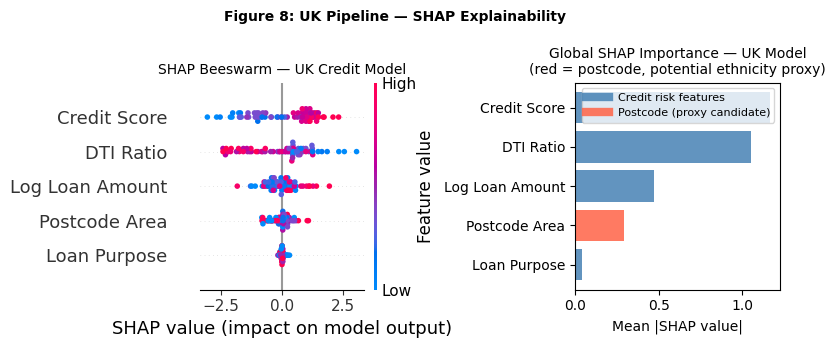

In [24]:
# Figure 8: UK SHAP Summary

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Beeswarm
plt.sca(axes[0])
shap.summary_plot(shap_values_uk, X_test_uk, feature_names=UK_FEAT_LABELS, show=False)
axes[0].set_title('SHAP Beeswarm — UK Credit Model', fontsize=10)

# Right: Bar chart of mean absolute SHAP
# Sort features
shap_series_uk = {}
for i, name in enumerate(UK_FEAT_LABELS):
    shap_series_uk[name] = mean_abs_shap_uk[i]

sorted_uk = sorted(shap_series_uk.items(), key=lambda x: x[1])
names_sorted_uk = [item[0] for item in sorted_uk]
values_sorted_uk = [item[1] for item in sorted_uk]

bar_colours_uk = []
for name in names_sorted_uk:
    if name == 'Postcode Area':
        bar_colours_uk.append('tomato')
    else:
        bar_colours_uk.append('steelblue')

axes[1].barh(names_sorted_uk, values_sorted_uk, color=bar_colours_uk, alpha=0.85)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Global SHAP Importance — UK Model\n(red = postcode, potential ethnicity proxy)', fontsize=10)

axes[1].plot([], [], color='steelblue', linewidth=6, label='Credit risk features', alpha=0.85)
axes[1].plot([], [], color='tomato', linewidth=6, label='Postcode (proxy candidate)', alpha=0.85)
axes[1].legend(fontsize=8)

plt.suptitle('Figure 8: UK Pipeline — SHAP Explainability', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 10 — Cross-Jurisdiction SHAP Comparison

This section brings the two pipelines together to show the core jurisdiction-aware design. Both pipelines detected the same type of signal — a geographic feature (zip code in the US, postcode area in the UK) showing up as relatively important in the model. But the response to that signal is completely different in each jurisdiction, because the regulatory frameworks are different.

| What the tool detected | US response | UK response |
|---|---|---|
| Geographic feature SHAP share > 15% | BISG race estimation + four-fifths check + CCO alert | Consumer Duty review flag + DPO notification |
| Regulatory basis | Regulation B / ECOA (state-law and litigation monitoring post-2026) | FCA Consumer Duty PS22/9 + Equality Act 2010 |
| Data used alongside SHAP | BISG probability vector | Self-declared ethnicity (where available) |
| Fairness metric | Four-fifths ratio (>= 0.80 per group) | Consumer Duty outcome category |

The point is that FairScope does not merge these — each application gets exactly one jurisdiction pipeline, and the rules for that pipeline come from the active jurisdiction config for that country.


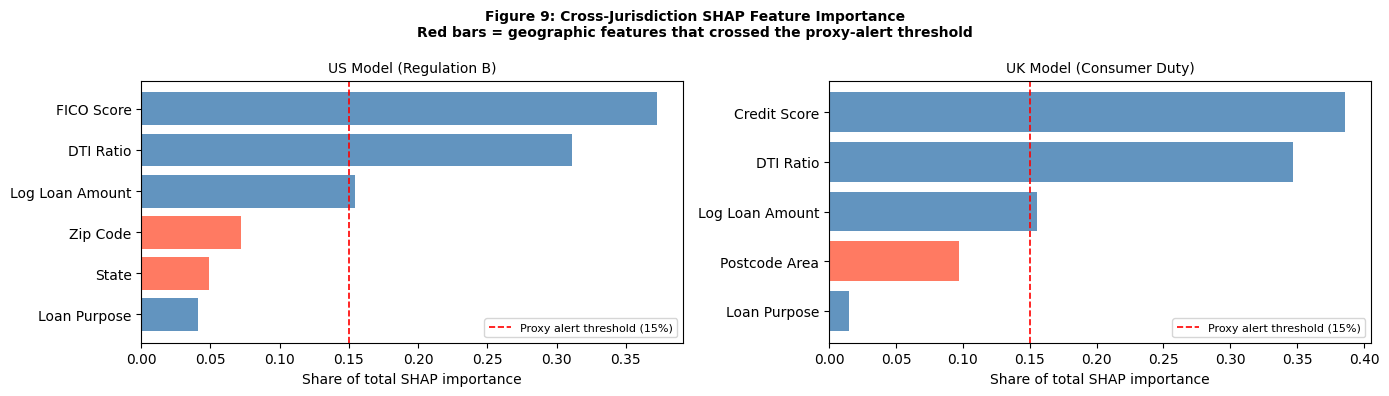

In [25]:
# Figure 9: Side-by-side SHAP importance for US vs UK
# This is the key cross-jurisdiction comparison chart

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Calculate normalised importance shares (% of total SHAP) for each model
us_shares = {}
for i, name in enumerate(US_FEAT_LABELS):
    us_shares[name] = mean_abs_shap_us[i] / mean_abs_shap_us.sum()

uk_shares = {}
for i, name in enumerate(UK_FEAT_LABELS):
    uk_shares[name] = mean_abs_shap_uk[i] / mean_abs_shap_uk.sum()

# US chart
sorted_us = sorted(us_shares.items(), key=lambda x: x[1])
us_names = [item[0] for item in sorted_us]
us_values = [item[1] for item in sorted_us]
us_colours = ['tomato' if n in ['Zip Code', 'State'] else 'steelblue' for n in us_names]

axes[0].barh(us_names, us_values, color=us_colours, alpha=0.85)
axes[0].axvline(
    US_CONFIG['shap_proxy_alert_threshold'],
    color='red', linestyle='--', linewidth=1.2,
    label='Proxy alert threshold (15%)'
)
axes[0].set_xlabel('Share of total SHAP importance')
axes[0].set_title('US Model (Regulation B)', fontsize=10)
axes[0].legend(fontsize=8)

# UK chart
sorted_uk_comp = sorted(uk_shares.items(), key=lambda x: x[1])
uk_names_comp = [item[0] for item in sorted_uk_comp]
uk_values_comp = [item[1] for item in sorted_uk_comp]
uk_colours_comp = ['tomato' if n == 'Postcode Area' else 'steelblue' for n in uk_names_comp]

axes[1].barh(uk_names_comp, uk_values_comp, color=uk_colours_comp, alpha=0.85)
axes[1].axvline(
    UK_CONFIG['shap_proxy_alert_threshold'],
    color='red', linestyle='--', linewidth=1.2,
    label='Proxy alert threshold (15%)'
)
axes[1].set_xlabel('Share of total SHAP importance')
axes[1].set_title('UK Model (Consumer Duty)', fontsize=10)
axes[1].legend(fontsize=8)

plt.suptitle(
    'Figure 9: Cross-Jurisdiction SHAP Feature Importance\n'
    'Red bars = geographic features that crossed the proxy-alert threshold',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [26]:
# Summary table of proxy monitoring results for both jurisdictions
print("Jurisdiction-Aware Proxy Monitoring Summary")
print("=" * 75)

us_zip_share = mean_abs_shap_us[US_FEATURES.index('zip_code_enc')] / mean_abs_shap_us.sum()
uk_pc_share = mean_abs_shap_uk[UK_FEATURES.index('postcode_area_enc')] / mean_abs_shap_uk.sum()
threshold = US_CONFIG['shap_proxy_alert_threshold']

print()
print("US Pipeline:")
print("  Feature monitored : Zip Code")
print("  SHAP share        :", str(round(us_zip_share * 100, 1)) + "%")
print("  Threshold         :", str(round(threshold * 100)) + "%")
if us_zip_share > threshold:
    print("  Status            : ALERT")
    print("  Action            : BISG + four-fifths check triggered. CCO notified.")
else:
    print("  Status            : OK")

print()
print("UK Pipeline:")
print("  Feature monitored : Postcode Area")
print("  SHAP share        :", str(round(uk_pc_share * 100, 1)) + "%")
print("  Threshold         :", str(round(threshold * 100)) + "%")
if uk_pc_share > threshold:
    print("  Status            : ALERT")
    print("  Action            : Consumer Duty review flag set. DPO notified.")
else:
    print("  Status            : OK")


Jurisdiction-Aware Proxy Monitoring Summary

US Pipeline:
  Feature monitored : Zip Code
  SHAP share        : 7.2%
  Threshold         : 15%
  Status            : OK

UK Pipeline:
  Feature monitored : Postcode Area
  SHAP share        : 9.7%
  Threshold         : 15%
  Status            : OK


## Section 11 — Compliance Report Generation

FairScope automatically populates the template for each compliance report. However, no report is submitted without human sign-off. This is consistent with the "Always Human" tier in the automation matrix described in the architecture document — HMDA filings, Consumer Duty board reports, and regulator exports all require CCO authorisation.


In [27]:
# US Compliance Report
print("=" * 65)
print("FAIRSCOPE — US COMPLIANCE REPORT (HMDA-STYLE AGGREGATE)")
print("Config applied:", US_CONFIG['config_id'])
print("Report date:", datetime.now().strftime('%Y-%m-%d'))
print("=" * 65)

total_us = len(us_df)
routed_correctly = us_df[us_df['route'] == 'us_pipeline'].shape[0]
inconclusive_count = us_df[us_df['bisg_inconclusive'] == True].shape[0]
overall_approval = us_df['approved'].mean()

print("Total applications processed  :", total_us)
print("Jurisdiction-routed correctly :", routed_correctly)
print("BISG inconclusive (human review):", inconclusive_count,
      "(" + str(round(inconclusive_count/total_us*100, 1)) + "%)")
print("Overall approval rate         :", str(round(overall_approval * 100, 1)) + "%")

print()
print("Approval rates by BISG-estimated race (conclusive cases only):")
for race, stats in approval_by_group.items():
    ratio = stats['approval_rate'] / best_rate
    if ratio < US_CONFIG['fairness_threshold']:
        status = "BREACH"
    else:
        status = "OK"
    print("  " + race.ljust(12) + ": " +
          str(round(stats['approval_rate']*100, 1)) + "%" +
          "  four-fifths ratio=" + str(round(ratio, 3)) +
          "  [" + status + "]")

print()
print("SHAP Proxy Monitoring:")
if us_zip_share > threshold:
    proxy_status = "ALERT — human review required"
else:
    proxy_status = "within threshold"
print("  zip_code importance share:", str(round(us_zip_share*100, 1)) + "% |",
      "threshold " + str(round(threshold*100)) + "% |", proxy_status)

print()
print("Outputs ready for human sign-off:")
print("  [ ] Regulation B adverse action notices (template populated)")
print("  [ ] HMDA LAR records (mortgage applications)")
print("  [ ] Internal disparity report")
print("  [ ] SHAP proxy audit memo")
print()
print("STATUS: PENDING CCO AUTHORISATION")


FAIRSCOPE — US COMPLIANCE REPORT (HMDA-STYLE AGGREGATE)
Config applied: US_CFPB_RegB_2026-04-15
Report date: 2026-05-20
Total applications processed  : 500
Jurisdiction-routed correctly : 500
BISG inconclusive (human review): 2 (0.4%)
Overall approval rate         : 48.6%

Approval rates by BISG-estimated race (conclusive cases only):
  Black       : 44.8%  four-fifths ratio=0.836  [OK]
  White       : 53.6%  four-fifths ratio=1.0  [OK]
  Asian       : 52.8%  four-fifths ratio=0.985  [OK]
  Hispanic    : 39.3%  four-fifths ratio=0.734  [BREACH]

SHAP Proxy Monitoring:
  zip_code importance share: 7.2% | threshold 15% | within threshold

Outputs ready for human sign-off:
  [ ] Regulation B adverse action notices (template populated)
  [ ] HMDA LAR records (mortgage applications)
  [ ] Internal disparity report
  [ ] SHAP proxy audit memo

STATUS: PENDING CCO AUTHORISATION


In [29]:
# UK Compliance Report
print("=" * 65)
print("FAIRSCOPE — UK COMPLIANCE REPORT (CONSUMER DUTY)")
print("Config applied:", UK_CONFIG['config_id'])
print("Report date:", datetime.now().strftime('%Y-%m-%d'))
print("=" * 65)

total_uk = len(uk_df)
uk_routed = uk_df[uk_df['route'] == 'uk_pipeline'].shape[0]
non_response_n = uk_df[uk_df['ethnicity_declared'] == False].shape[0]
uk_approval_rate = uk_df['approved'].mean()

print("Total applications processed   :", total_uk)
print("Jurisdiction-routed correctly  :", uk_routed)
print("Non-response (Prefer not to say):", non_response_n,
      "(" + str(round(non_response_n/total_uk*100, 1)) + "%) — excluded from group analysis")
print("Overall approval rate          :", str(round(uk_approval_rate * 100, 1)) + "%")

print()
print("Consumer Duty Outcome Distribution:")
for outcome, count in uk_df['cd_outcome'].value_counts().items():
    pct = round(count / total_uk * 100, 1)
    print("  " + outcome.ljust(38) + ":" + str(count).rjust(5) + " (" + str(pct) + "%)")

print()
print("Approval rates by declared ethnicity:")
for eth, rate in sorted(uk_approval_rates.items(), key=lambda x: x[1], reverse=True):
    n = declared_only[declared_only['ethnicity'] == eth].shape[0]
    print("  " + eth.ljust(22) + ": " + str(round(rate*100, 1)) + "%" + "  (n=" + str(n) + ")")

print()
print("SHAP Proxy Monitoring:")
if uk_pc_share > threshold:
    proxy_status_uk = "ALERT — Consumer Duty review + DPO notification"
else:
    proxy_status_uk = "within threshold"
print("  postcode_area importance share:", str(round(uk_pc_share*100, 1)) + "% |",
      "threshold " + str(round(threshold*100)) + "% |", proxy_status_uk)

print()
print("Outputs ready for human sign-off:")
print("  [ ] Consumer Duty outcome records")
print("  [ ] Data-protection note on special-category data processing")
print("  [ ] Internal monitoring feed (annual board report)")
print("  [ ] SHAP proxy audit memo")
print()
print("STATUS: PENDING CCO AUTHORISATION")


FAIRSCOPE — UK COMPLIANCE REPORT (CONSUMER DUTY)
Config applied: UK_FCA_ConsumerDuty_2023-07-31
Report date: 2026-05-20
Total applications processed   : 300
Jurisdiction-routed correctly  : 300
Non-response (Prefer not to say): 75 (25.0%) — excluded from group analysis
Overall approval rate          : 68.0%

Consumer Duty Outcome Distribution:
  Good outcome                          :  204 (68.0%)
  Review required                       :   77 (25.7%)
  Fair outcome - financial risk         :   19 (6.3%)

Approval rates by declared ethnicity:
  Asian British         : 77.4%  (n=31)
  White British         : 74.7%  (n=150)
  Other                 : 61.5%  (n=13)
  Mixed                 : 53.3%  (n=15)
  Black British         : 37.5%  (n=16)

SHAP Proxy Monitoring:
  postcode_area importance share: 9.7% | threshold 15% | within threshold

Outputs ready for human sign-off:
  [ ] Consumer Duty outcome records
  [ ] Data-protection note on special-category data processing
  [ ] Internal mon

## Summary and Reflection

This notebook demonstrates FairScope, a jurisdiction-aware fair lending compliance tool for HSBC's US and UK retail credit business. The core idea is that the same credit application data needs to go through different compliance checks depending on the regulatory framework of the country.

**What the two pipelines do differently:**

| | US Pipeline | UK Pipeline |
|---|---|---|
| Regulation | Regulation B / ECOA | FCA Consumer Duty + Equality Act 2010 |
| How race/ethnicity is estimated | BISG (surname + zip code) | Voluntary self-declaration only |
| ML model | Gradient Boosting — 6 features | Gradient Boosting — 5 features |
| Explainability | SHAP TreeExplainer | SHAP TreeExplainer |
| Proxy detection method | Zip code SHAP share > 15% → BISG + four-fifths | Postcode SHAP share > 15% → Consumer Duty flag |
| Fairness metric | Four-fifths ratio (>= 0.80) | Consumer Duty outcome category |
| Alert recipient | CCO | Compliance officer + DPO |

**Why SHAP is included:**
Neither Regulation B nor Consumer Duty explicitly requires SHAP analysis. I included it because both frameworks require firms to demonstrate they understand their models and that the models are not producing unfair outcomes. SHAP gives an early warning — a proxy risk can appear in SHAP importance before it shows up as a statistically significant disparity in approval rates. That gives the compliance team time to investigate before there is a reportable breach.

**limitations:**
- The data is synthetic — in a real deployment the model being explained would be HSBC's actual underwriting model, not one I trained on synthetic data
- BISG is an estimate, not a measurement — it will misclassify some applicants, especially those with uncommon or cross-cultural surnames
- The UK non-response rate (~30%) means the declared-group analysis only covers about 70% of UK applicants
- This prototype only covers federal US rules (Regulation B) — state-level rules are not implemented
